Permutation testing for the big bins I have, take random samples and see if the effects replicate

In [49]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np
from tqdm import tqdm
import nibabel as nib
from nilearn import plotting
from nilearn.datasets import load_mni152_template
from nilearn.image import new_img_like
import seaborn as sns

In [50]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
# keep only classification_label=1 and snbb
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

min_age = 40
max_age = 45

# volumes df
volumes = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] < max_age)]
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')

# metadata df
# remove duplicates based on subject_id
metadata = volumes.drop_duplicates(subset=['subject_id'])
print(f"shape of {min_age} - {max_age} years old metadata after removing duplicates: {metadata.shape}")

atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")


shape of 40 - 45 years old metadata after removing duplicates: (224, 25)


/tmp/ipykernel_36738/3707351218.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')


In [51]:


# --- 1. Permutation Setup ---
N_PERMUTATIONS = 1000
SAMPLE_SIZE = 50
all_session_ids = volumes['session_id'].unique()
# roi_list = volumes['region_label'].unique()
roi_list = [421]

# Dictionary to store Coefficients (beta) for birth_year across runs
coef_accumulator = {roi: [] for roi in roi_list}

print(f"Running {N_PERMUTATIONS} stability permutations for Coefficients...")

for i in tqdm(range(N_PERMUTATIONS)):
    selected_subjects = np.random.choice(all_session_ids, size=SAMPLE_SIZE, replace=False)
    df_sample = volumes[volumes['session_id'].isin(selected_subjects)]
    
    for roi, df_roi in df_sample.groupby('region_label'):
        if roi not in roi_list:
            continue
        try:
            model = smf.ols(
                'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
                data=df_roi
            ).fit()
            # CHANGED: Collect coefficient (params) instead of tvalues
            coef_accumulator[roi].append(model.params['birth_year'])
        except:
            continue

# --- 2. Calculate Mean Coefficients ---
mean_coef_map = {roi: np.nanmean(coef_vals) for roi, coef_vals in coef_accumulator.items() if coef_vals}



Running 1000 stability permutations for Coefficients...


100%|██████████| 1000/1000 [00:18<00:00, 53.89it/s]


# visualize on the brain

Mapping mean coefficients to atlas voxels...


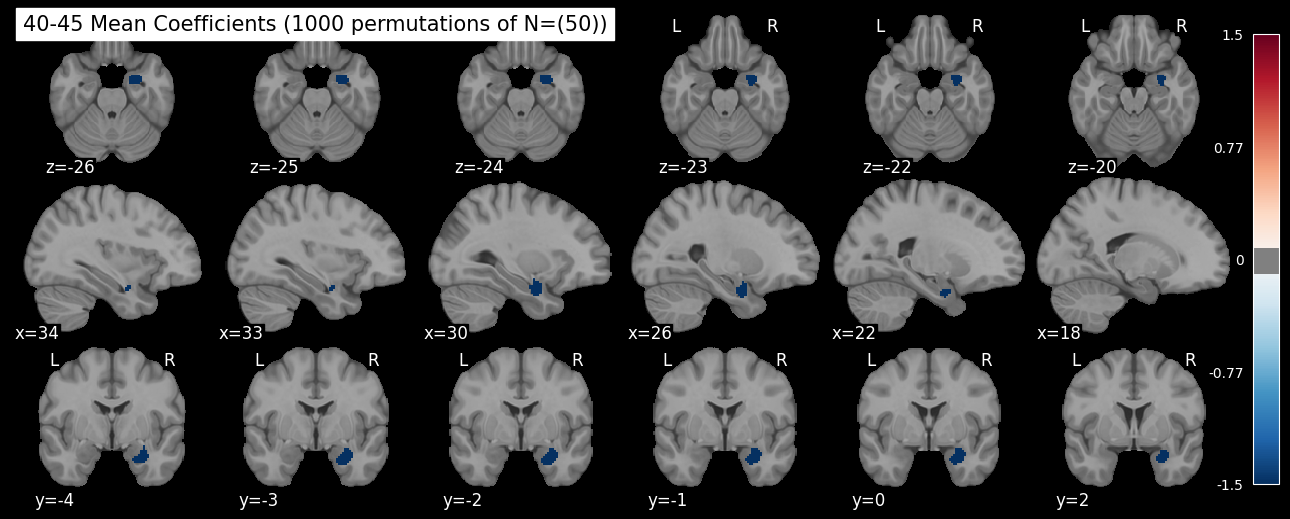

In [52]:
# --- 3. Map Results to Atlas Space ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

stat_map_data = np.zeros_like(atlas_labels, dtype=float)

print("Mapping mean coefficients to atlas voxels...")
for label, mean_coef in mean_coef_map.items():
    stat_map_data[atlas_labels == label] = mean_coef

coef_map_img = new_img_like(atlas_img, stat_map_data)

# --- 4. Plotting ---
bg_img = load_mni152_template()
custom_cut_coords = (6, 6, 6)

plotting.plot_stat_map(
    stat_map_img=coef_map_img,
    bg_img=bg_img,
    title=f"{min_age}-{max_age} Mean Coefficients ({N_PERMUTATIONS} permutations of N=({SAMPLE_SIZE}))",
    cmap='RdBu_r', # Red = Volume increase per year, Blue = Volume decrease
    symmetric_cbar=True,
    threshold=0.1, # Adjusted: Coefs can be small; set this based on your expected effect size
    display_mode='mosaic',
    cut_coords=custom_cut_coords,
    colorbar=True
)

plotting.show()

# visualize coefficient distribution

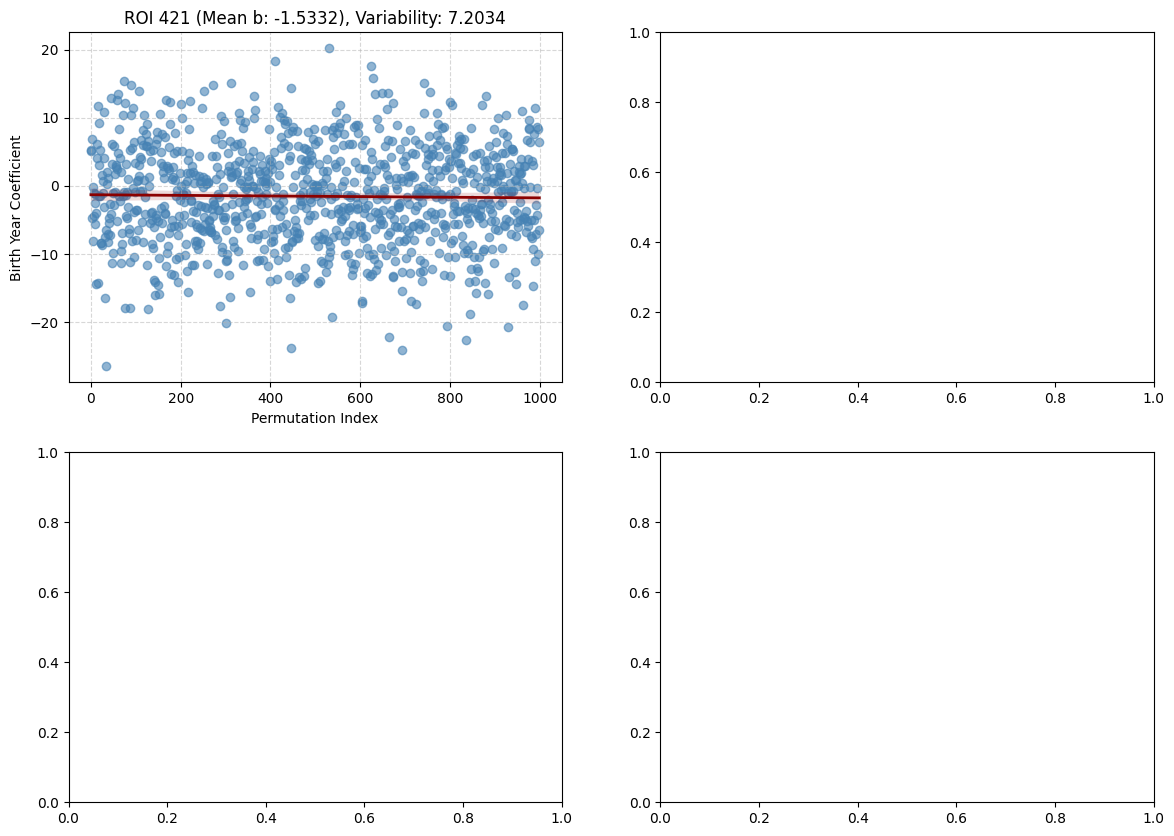

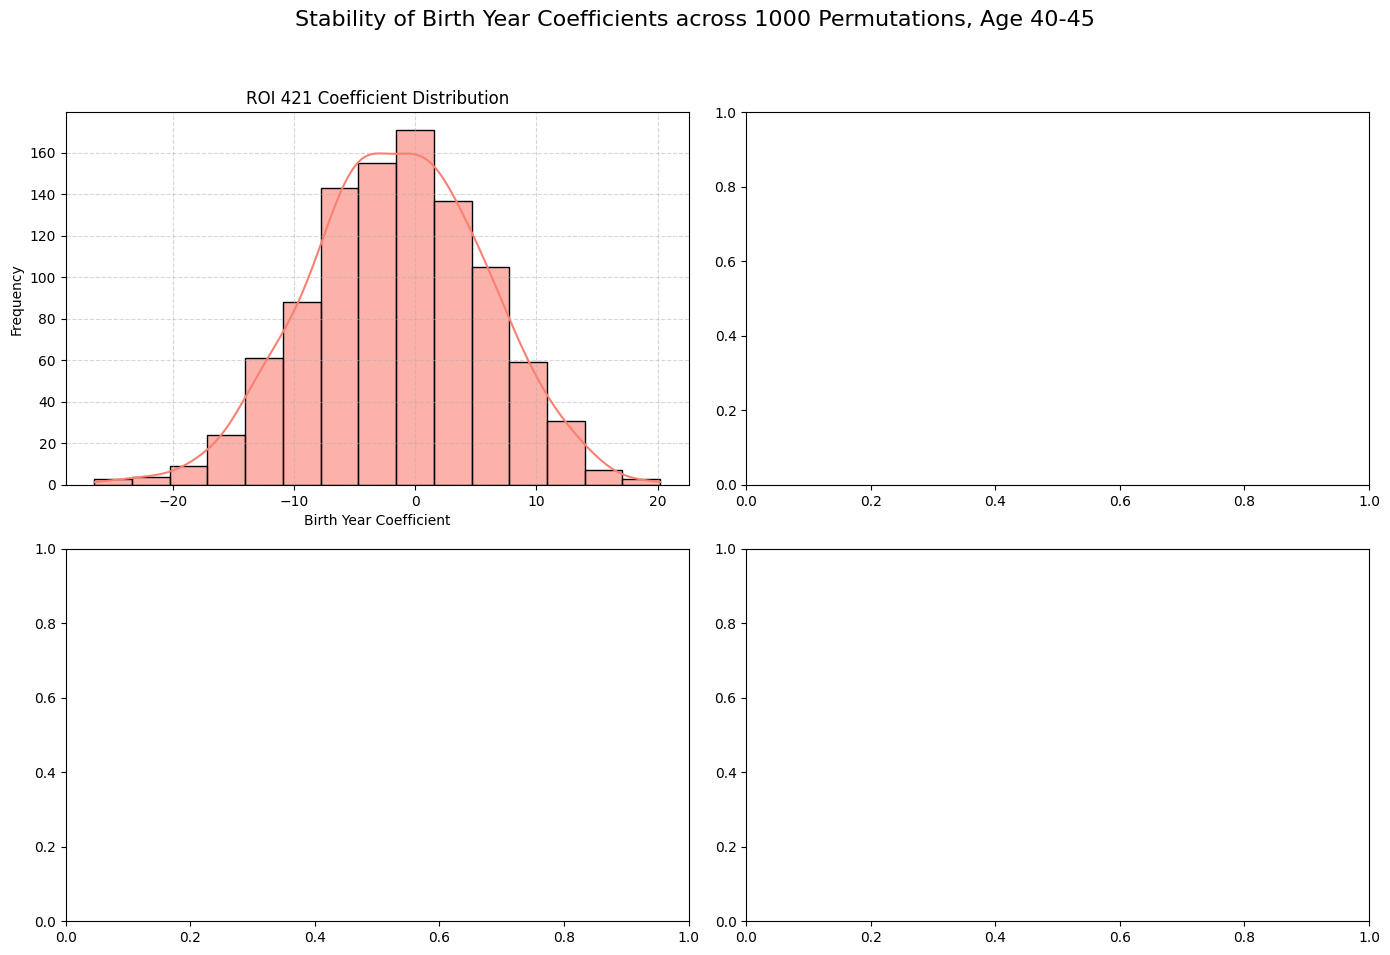

In [53]:

# --- 2. Visualization: Specific ROI Scatter Plots ---
# Create 2 plots with 2x2 grid for the 4 target ROIs
fig1, axes = plt.subplots(2, 2, figsize=(14, 10)) # scatter plots
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10)) # histograms
axes = axes.flatten()
axes2 = axes2.flatten()

for i, roi in enumerate(roi_list):
    if roi in coef_accumulator and len(coef_accumulator[roi]) > 0:
        # Create a temporary dataframe for this ROI's results
        df_roi_viz = pd.DataFrame({
            'Permutation': range(len(coef_accumulator[roi])),
            'Beta': coef_accumulator[roi]
        })
        
        # Plot scatter + regression line
        sns.regplot(
            data=df_roi_viz,
            x='Permutation',
            y='Beta',
            ax=axes[i],
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
            line_kws={'color': 'darkred', 'lw': 2}
        )
        
        # Plot histogram
        sns.histplot(
            data=df_roi_viz,
            x='Beta',
            bins=15,
            kde=True,
            ax=axes2[i],
            color='salmon',
            alpha=0.6
        )
        
        # Calculate mean and stats for the title of both plots
        mean_val = np.mean(coef_accumulator[roi])
        axes[i].set_title(f'ROI {roi} (Mean b: {mean_val:.4f}), Variability: {np.std(coef_accumulator[roi]):.4f}')
        axes[i].set_xlabel('Permutation Index')
        axes[i].set_ylabel('Birth Year Coefficient')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes2[i].set_title(f'ROI {roi} Coefficient Distribution')
        axes2[i].set_xlabel('Birth Year Coefficient')
        axes2[i].set_ylabel('Frequency')
        axes2[i].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[i].set_title(f'ROI {roi} (No data available)')
        axes2[i].set_title(f'ROI {roi} (No data available)')


plt.suptitle(f'Stability of Birth Year Coefficients across {N_PERMUTATIONS} Permutations, Age {min_age}-{max_age}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 

# distribution comparison

In [54]:
results = []

# Loop only through the regions present in both your list and the data
for region in roi_list:
    if region in coef_accumulator:
        coefs_array = np.array(coef_accumulator[region])
        
        # Calculate stats
        mean_coef = np.mean(coefs_array)
        lower_bound = np.percentile(coefs_array, 2.5)
        upper_bound = np.percentile(coefs_array, 97.5)
        
        # Determine significance (CI does not contain 0)
        is_significant = not (lower_bound <= 0 <= upper_bound)
        
        results.append({
            'region': region,
            'mean_coef': mean_coef,
            'ci_lower': lower_bound,
            'ci_upper': upper_bound,
            'significant': is_significant
        })
    else:
        print(f"Warning: Region {region} not found in coef_accumulator.")

# Create summary DataFrame
df_roi_summary = pd.DataFrame(results)

# Quick view of the selected ROIs
print(df_roi_summary)

   region  mean_coef   ci_lower   ci_upper  significant
0     421  -1.533185 -15.719213  12.153013        False
